In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fsm2 = xr.open_dataset("../data/FSM2/fsm2_sd_2023.nc")
sen  = xr.open_dataset("../data/seNorge/sd_2023.nc")

print("FSM2 vars:", list(fsm2.data_vars))
print("seNorge vars:", list(sen.data_vars))

FSM2 vars: ['snow_depth', 'UTM_Zone_33']
seNorge vars: ['snow_depth', 'UTM_Zone_33']


In [3]:
fsm_var = "snow_depth"
sen_var = list(sen.data_vars)[0]   # midlertidig: tar første variabel
print("Using seNorge variable:", sen_var)

Using seNorge variable: snow_depth


In [4]:
target_lat, target_lon = 61.5, 8.5

# FSM2 nærmeste punkt
dist2_f = (fsm2["lat"].values - target_lat)**2 + (fsm2["lon"].values - target_lon)**2
iy, ix = np.unravel_index(np.argmin(dist2_f), dist2_f.shape)

# seNorge nærmeste punkt
dist2_s = (sen["lat"].values - target_lat)**2 + (sen["lon"].values - target_lon)**2
jy, jx = np.unravel_index(np.argmin(dist2_s), dist2_s.shape)

print("FSM2 lat/lon:", float(fsm2["lat"].isel(y=iy, x=ix).values), float(fsm2["lon"].isel(y=iy, x=ix).values))
print("seNorge lat/lon:", float(sen["lat"].isel(y=jy, x=jx).values), float(sen["lon"].isel(y=jy, x=jx).values))

FSM2 lat/lon: 61.501998044511744 8.492293150156435
seNorge lat/lon: 61.501998044511744 8.492293150156435


FSM2 units: mm
seNorge units: cm


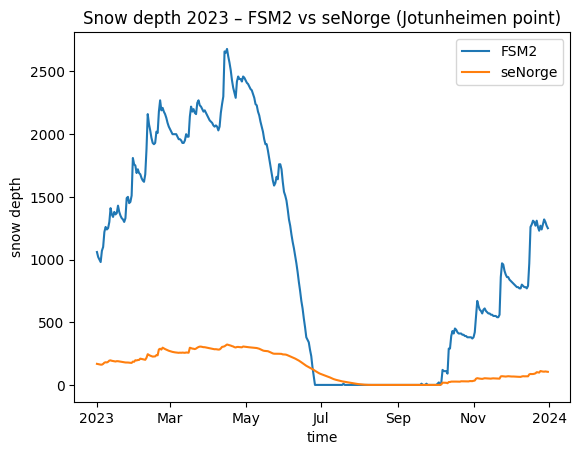

In [5]:
fsm_ts = fsm2[fsm_var].isel(y=iy, x=ix)
sen_ts = sen[sen_var].isel(y=jy, x=jx)

# Enhetsjekk (kan være m vs mm)
print("FSM2 units:", fsm_ts.attrs.get("units"))
print("seNorge units:", sen_ts.attrs.get("units"))

plt.figure()
fsm_ts.plot(label="FSM2")
sen_ts.plot(label="seNorge")
plt.legend()
plt.title("Snow depth 2023 – FSM2 vs seNorge (Jotunheimen point)")
plt.ylabel("snow depth")
plt.show()

In [6]:
print("FSM2 units:", fsm2["snow_depth"].attrs.get("units"))
print("seNorge units:", sen[sen_var].attrs.get("units"))

FSM2 units: mm
seNorge units: cm


In [7]:
sen_ts = sen_ts * 10  

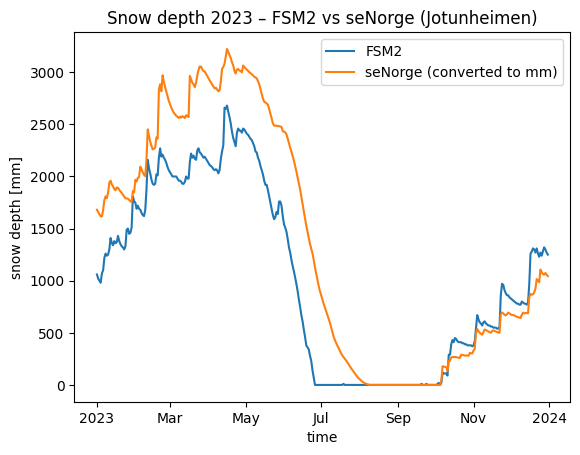

In [8]:
plt.figure()
fsm_ts.plot(label="FSM2")
sen_ts.plot(label="seNorge (converted to mm)")
plt.legend()
plt.title("Snow depth 2023 – FSM2 vs seNorge (Jotunheimen)")
plt.ylabel("snow depth [mm]")
plt.show()

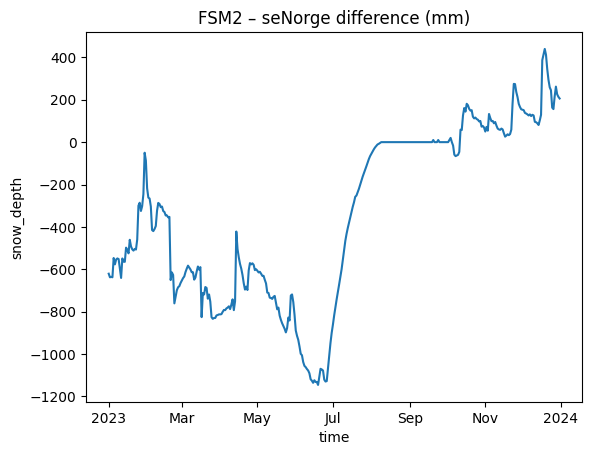

In [9]:
diff = fsm_ts - sen_ts

plt.figure()
diff.plot()
plt.title("FSM2 – seNorge difference (mm)")
plt.show()

In [10]:
print("Mean bias (mm):", float(diff.mean()))

rmse = np.sqrt(((fsm_ts - sen_ts)**2).mean())
print("RMSE (mm):", float(rmse))

Mean bias (mm): -341.14794921875
RMSE (mm): 531.4686279296875


In [11]:
print("FSM2 max:", float(fsm_ts.max()))
print("seNorge max:", float(sen_ts.max()))

FSM2 max: 2680.0
seNorge max: 3224.0


In [12]:
print("FSM2 max date:", str(fsm_ts.idxmax().values))
print("seNorge max date:", str(sen_ts.idxmax().values))

FSM2 max date: 2023-04-16T00:00:00.000000000
seNorge max date: 2023-04-16T00:00:00.000000000
